[INFO] Processing lag data...
  - Reading file: results_HT_delay_1.csv ...
  - Reading file: results_HT_delay_5.csv ...
  - Reading file: results_HT_delay_10.csv ...
  - Reading file: results_HT_delay_15.csv ...
  - Reading file: results_HT_delay_20.csv ...
  - Reading file: results_HT_delay_25.csv ...
  - Reading file: results_HT_delay_30.csv ...
  - Reading file: results_HT_delay_35.csv ...
  - Reading file: results_HT_delay_40.csv ...

DETAILED REPORT: ACCURACY AND KAPPA BY LAG
             Domain  Lag  Asset_Count  Accuracy_Exact  Kappa_Exact
 Fundamental Domain    1           58         0.51053     -0.02269
 Fundamental Domain    5           58         0.50839     -0.02717
 Fundamental Domain   10           58         0.50645     -0.03082
 Fundamental Domain   15           58         0.50579     -0.03183
 Fundamental Domain   20           58         0.50525     -0.03466
 Fundamental Domain   25           58         0.50543     -0.03694
 Fundamental Domain   30           58        

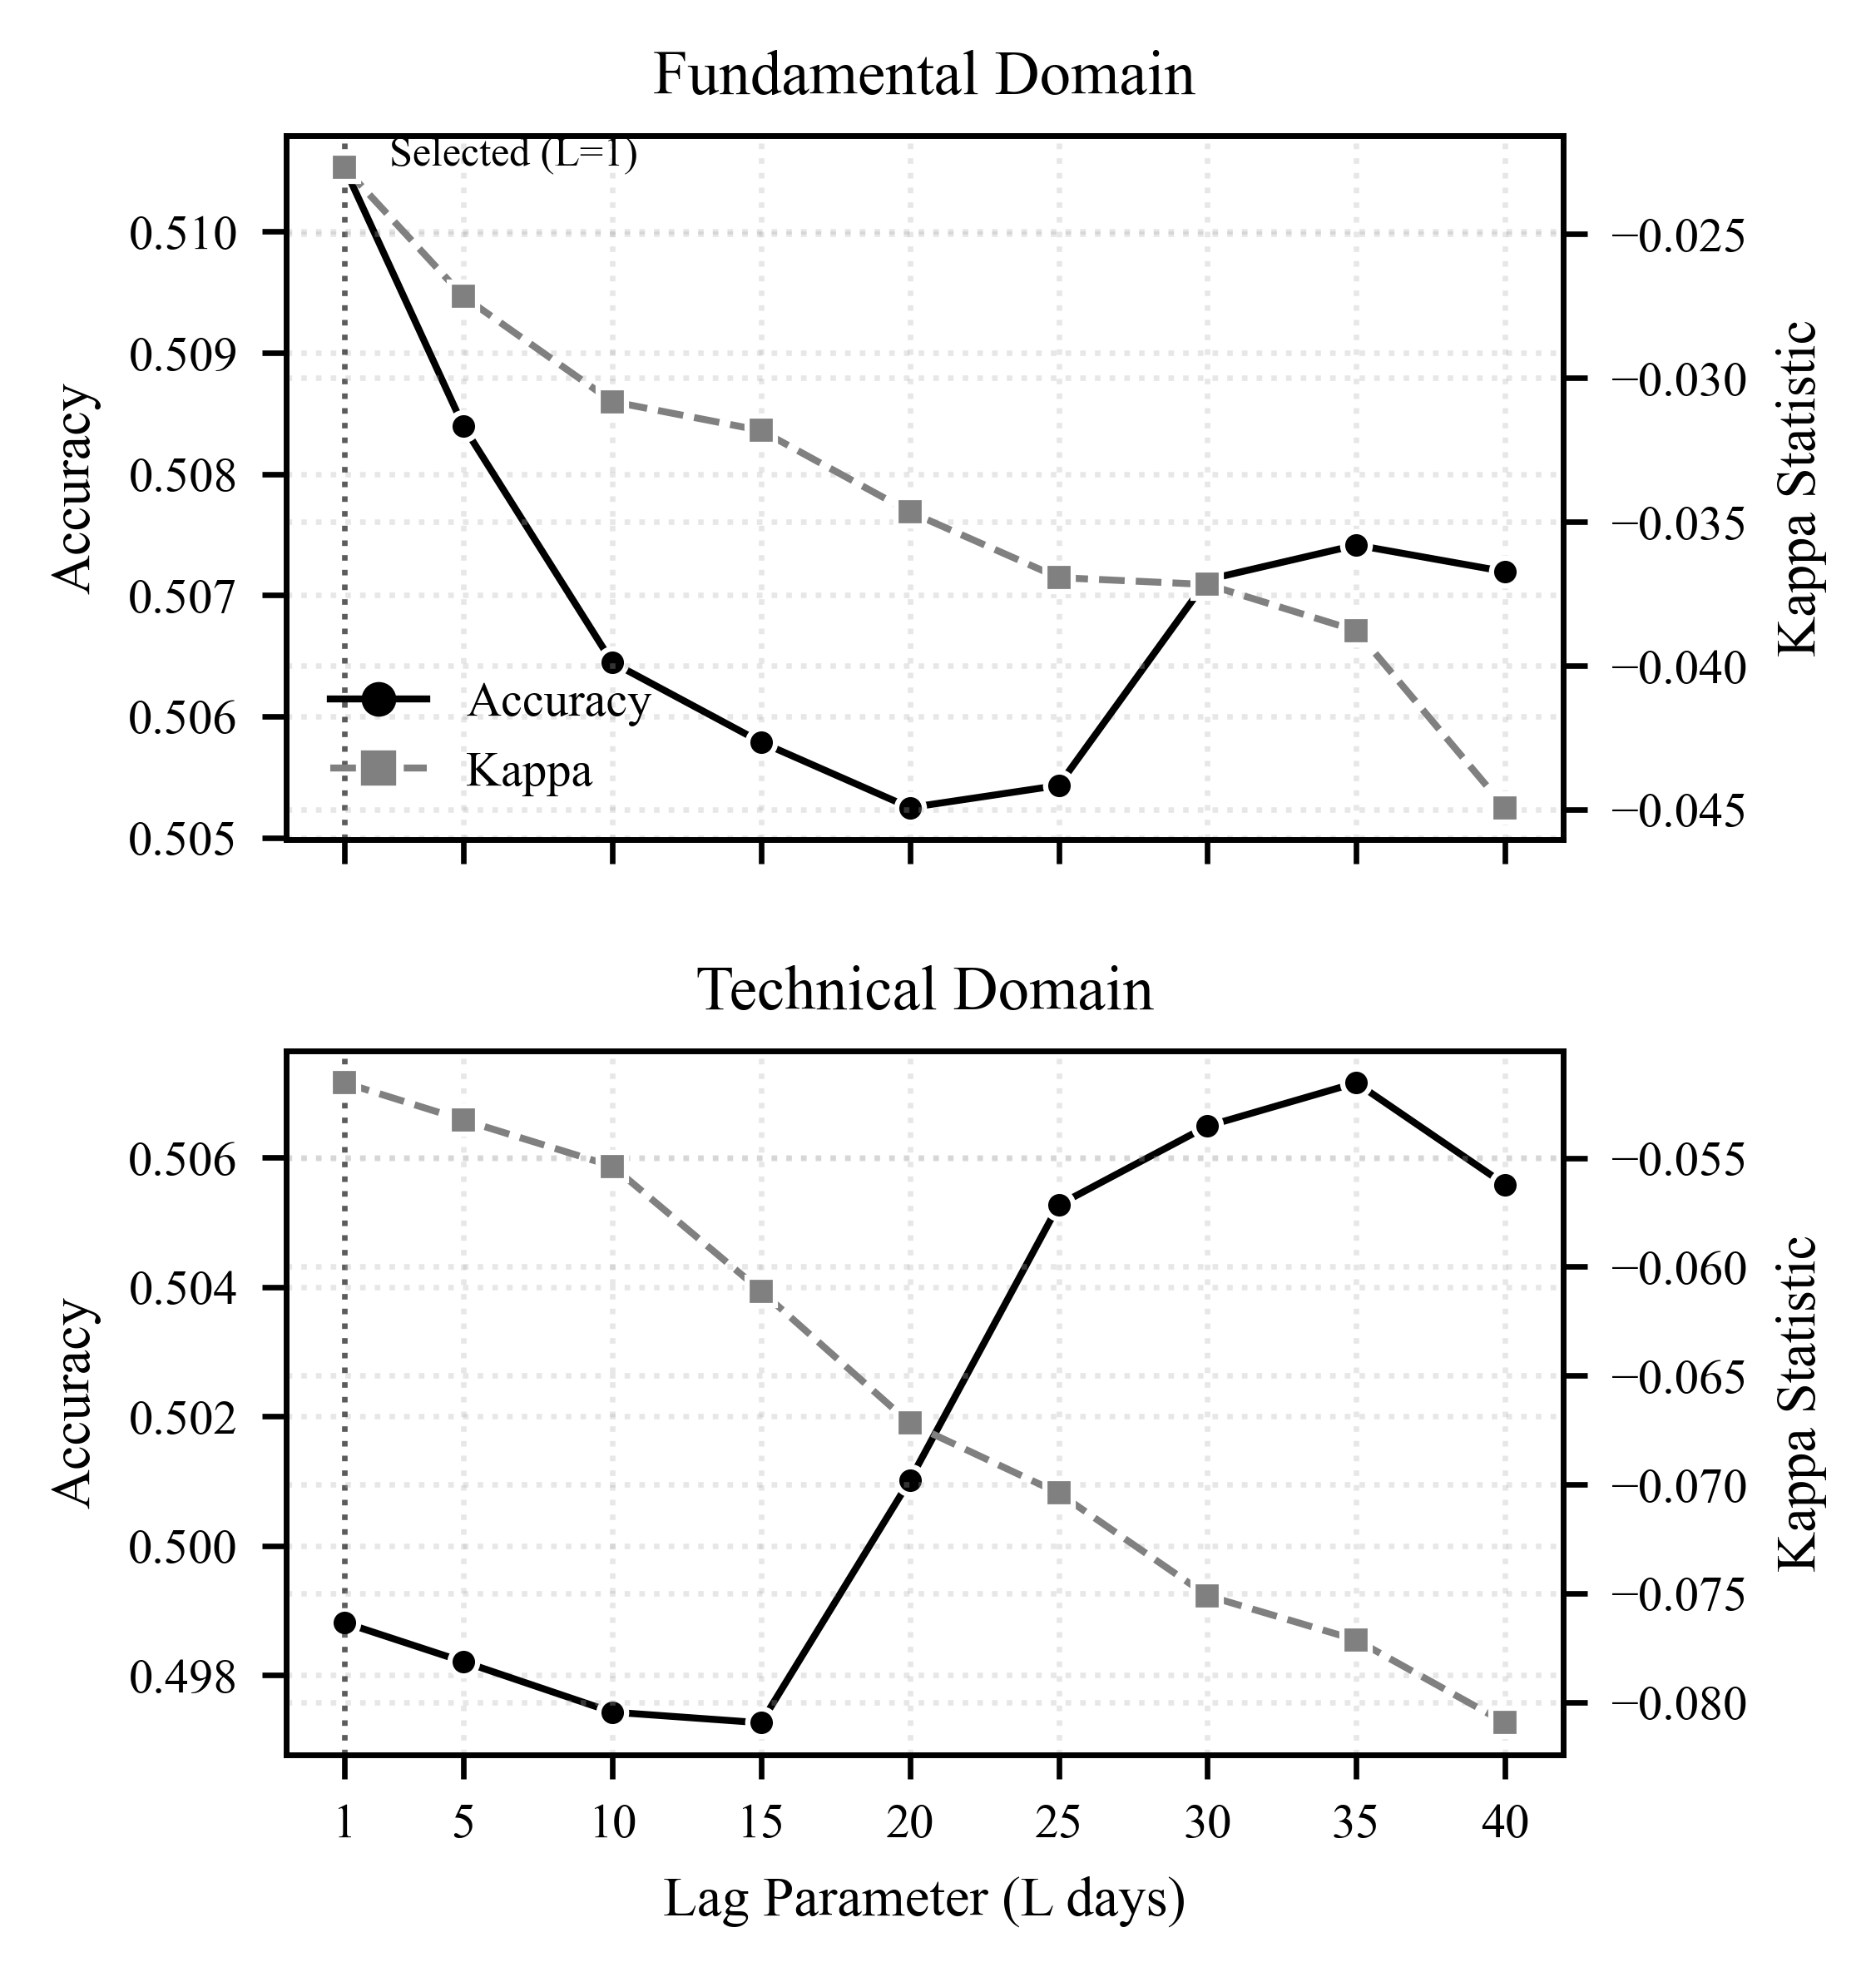

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm

# ==============================================================================
# 1. CONFIGURATIONS
# ==============================================================================
model_name = 'HT'
delays = [1, 5, 10, 15, 20, 25, 30, 35, 40]
base_path = 'results'
stock_path = '/home/jjos/profit_performance/valor_mobiliario.csv' # Check this path
SELECTED_LAG = 1 

# Lists to store data
plot_data = []   # For the chart
report_data = [] # For the CSV table

# Font Configuration (Times New Roman)
font_path = os.path.expanduser('~/.local/share/fonts/times.ttf') 
if not os.path.exists(font_path):
    font_path = os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf')

try:
    fm.fontManager.addfont(font_path)
    font_prop = fm.FontProperties(fname=font_path)
    font_family_name = font_prop.get_name()
except Exception:
    font_family_name = 'serif'

# IEEE Style Configuration
color_acc = 'black'       
color_kap = 'black'
style_acc = '-'
style_kap = '--'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': [font_family_name],
    'font.size': 8,              
    'axes.labelsize': 8,         
    'axes.titlesize': 9,         
    'legend.fontsize': 7,        
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,           
    'lines.linewidth': 1.0,      
    'lines.markersize': 4,       
    'axes.grid': True,           
    'grid.alpha': 0.3,           
    'grid.linestyle': ':'
})

domain_map = {'fund': 'Fundamental Domain', 'nao_fund': 'Technical Domain'}

# ==============================================================================
# 2. PROCESSING (MAIN LOOP)
# ==============================================================================
print(f"[INFO] Processing lag data...")

if os.path.exists(base_path):
    for delay in delays:
        
        filename = f'results_{model_name}_delay_{delay}.csv'
        full_path = os.path.join(base_path, filename)
        
        try:
            if not os.path.exists(full_path): 
                continue
                
            print(f"  - Reading file: {filename} ...")
            df = pd.read_csv(full_path)
            
            # --- ASSET FILTERING (CRITICAL) ---
            try:
                # Load liquidity/year filter if necessary
                if os.path.exists(stock_path):
                    df_stock = pd.read_csv(stock_path)
                    
                    # Assuming 'Data_Referencia' and 'Codigo_Negociacao' are the exact column names in your CSV
                    if not pd.api.types.is_datetime64_any_dtype(df_stock['Data_Referencia']):
                        df_stock['Data_Referencia'] = pd.to_datetime(df_stock['Data_Referencia'], errors='coerce')

                    # Extract valid tickers for 2023
                    valid_tickers = df_stock[df_stock['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
                    
                    df = df[df['dataset'].isin(valid_tickers)]
                    df = df[~df['dataset'].isin(['LEVE3'])] # Explicit exclusion due to price adjustment errors
                
                # Count remaining unique assets for this Lag after filtering
                asset_count = df['dataset'].nunique()
                
            except Exception as e:
                print(f"[ERROR] Filter error (Lag {delay}): {e}")
                asset_count = df['dataset'].nunique() if 'dataset' in df.columns else 0

            # --- DATA COLLECTION FOR CHART AND REPORT ---
            for cat_code, cat_name in domain_map.items():
                df_filtered = df[df['category'] == cat_code]
                
                if not df_filtered.empty:
                    acc_mean = df_filtered['Accuracy'].mean()
                    kap_mean = df_filtered['Kappa'].mean()
                    
                    # 1. Data for Plot
                    plot_data.append({
                        'Lag_Int': delay,
                        'Domain': cat_name,
                        'Accuracy': acc_mean,
                        'Kappa': kap_mean
                    })
                    
                    # 2. Data for Detailed Report
                    report_data.append({
                        'Lag': delay,
                        'Domain': cat_name,
                        'Asset_Count': asset_count,
                        'Accuracy_Exact': acc_mean,
                        'Kappa_Exact': kap_mean
                    })

        except Exception as e:
            print(f"[ERROR] Failed to process {filename}: {e}")
else:
    print(f"[WARNING] Base path '{base_path}' does not exist.")

# ==============================================================================
# 3. GENERATE TABULAR REPORT
# ==============================================================================
df_report = pd.DataFrame(report_data)

if not df_report.empty:
    # Sort
    df_report = df_report.sort_values(['Domain', 'Lag'])
    
    # Reorder columns
    cols = ['Domain', 'Lag', 'Asset_Count', 'Accuracy_Exact', 'Kappa_Exact']
    df_report = df_report[cols]
    
    print("\n" + "="*80)
    print("DETAILED REPORT: ACCURACY AND KAPPA BY LAG")
    print("="*80)
    
    # Display with 5 decimal places
    print(df_report.to_string(index=False, float_format="%.5f"))
    
    df_report.to_csv('report_exact_lag.csv', index=False, float_format="%.5f")
    print("\n[INFO] Report saved to: report_exact_lag.csv")
else:
    print("[WARNING] No data found to generate the report.")

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
if plot_data:
    df_plot = pd.DataFrame(plot_data).sort_values('Lag_Int')
    
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(3.8, 4.0), sharex=True)

    def plot_ieee_dual_axis(ax_primary, data, title):
        sns.lineplot(data=data, x='Lag_Int', y='Accuracy', ax=ax_primary, 
                     color=color_acc, marker='o', linestyle=style_acc, 
                     legend=False, ci=None) 
        
        ax_primary.set_ylabel('Accuracy', color=color_acc)
        ax_primary.tick_params(axis='y', labelcolor=color_acc)
        
        ax_secondary = ax_primary.twinx() 
        sns.lineplot(data=data, x='Lag_Int', y='Kappa', ax=ax_secondary, 
                     color="grey", marker='s', linestyle=style_kap, 
                     legend=False, ci=None)
        
        ax_secondary.set_ylabel('Kappa Statistic', color=color_kap)
        ax_secondary.tick_params(axis='y', labelcolor=color_kap)
        
        ax_primary.set_title(title, pad=6)
        ax_primary.axvline(x=SELECTED_LAG, color='black', linestyle=':', linewidth=0.8, alpha=0.6)
        
        return ax_secondary

    data_fund = df_plot[df_plot['Domain'] == 'Fundamental Domain']
    plot_ieee_dual_axis(ax_top, data_fund, 'Fundamental Domain')
    
    y_limits = ax_top.get_ylim()
    ax_top.text(SELECTED_LAG + 1.5, y_limits[1], f"Selected (L={SELECTED_LAG})", 
                color='black', fontsize=6, va='top', ha='left')

    data_tech = df_plot[df_plot['Domain'] == 'Technical Domain']
    plot_ieee_dual_axis(ax_bottom, data_tech, 'Technical Domain')

    ax_bottom.set_xlabel('Lag Parameter (L days)')
    ax_bottom.set_xticks(delays)

    legend_elements = [
        Line2D([0], [0], color=color_acc, lw=1, marker='o', markersize=4, label='Accuracy'),
        Line2D([0], [0], color="grey", lw=1, linestyle=style_kap, marker='s', markersize=4, label='Kappa')
    ]
    ax_top.legend(handles=legend_elements, loc='lower left', frameon=False, 
                  bbox_to_anchor=(0, 0), fontsize=7, ncol=1)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) 
    
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/lag_sensitivity.pdf', format='pdf', dpi=600, bbox_inches='tight')
    plt.show()